Link penjelasan : https://drive.google.com/drive/folders/1FIH1Caparvn7M8SfCOoY2nm8-doBMkJE?usp=sharing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN
import math
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
import pickle as pkl


In [3]:
df = pd.read_csv("C:/Users/BN124662615/Downloads/UAS MODEL DEPLOYMENT/data_1D.csv")

# EXPLORATION

In [4]:
df.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,0,83,retired,divorced,basic.4y,no,no,no,cellular,nov,tue,242.0,1,3,3,success,yes
1,1,32,services,married,high.school,no,no,no,telephone,may,tue,190.0,3,999,0,nonexistent,no
2,2,31,admin.,single,university.degree,no,yes,no,telephone,may,wed,325.0,2,999,0,nonexistent,no
3,3,33,admin.,single,university.degree,no,yes,no,telephone,aug,thu,158.0,1,999,0,nonexistent,no
4,4,39,services,married,high.school,no,yes,no,telephone,jul,mon,158.0,1,999,0,nonexistent,no


In [5]:
df = df.drop(columns=['Unnamed: 0'])

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,83,retired,divorced,basic.4y,no,no,no,cellular,nov,tue,242.0,1,3,3,success,yes
1,32,services,married,high.school,no,no,no,telephone,may,tue,190.0,3,999,0,nonexistent,no
2,31,admin.,single,university.degree,no,yes,no,telephone,may,wed,325.0,2,999,0,nonexistent,no
3,33,admin.,single,university.degree,no,yes,no,telephone,aug,thu,158.0,1,999,0,nonexistent,no
4,39,services,married,high.school,no,yes,no,telephone,jul,mon,158.0,1,999,0,nonexistent,no


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8238 entries, 0 to 8237
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          8238 non-null   int64  
 1   job          8230 non-null   object 
 2   marital      8238 non-null   object 
 3   education    8238 non-null   object 
 4   default      8238 non-null   object 
 5   housing      8238 non-null   object 
 6   loan         8238 non-null   object 
 7   contact      8238 non-null   object 
 8   month        8238 non-null   object 
 9   day_of_week  8238 non-null   object 
 10  duration     8226 non-null   float64
 11  campaign     8238 non-null   int64  
 12  pdays        8238 non-null   int64  
 13  previous     8238 non-null   int64  
 14  poutcome     8238 non-null   object 
 15  y            8238 non-null   object 
dtypes: float64(1), int64(4), object(11)
memory usage: 1.0+ MB


In [8]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,83,retired,divorced,basic.4y,no,no,no,cellular,nov,tue,242.0,1,3,3,success,yes
1,32,services,married,high.school,no,no,no,telephone,may,tue,190.0,3,999,0,nonexistent,no
2,31,admin.,single,university.degree,no,yes,no,telephone,may,wed,325.0,2,999,0,nonexistent,no
3,33,admin.,single,university.degree,no,yes,no,telephone,aug,thu,158.0,1,999,0,nonexistent,no
4,39,services,married,high.school,no,yes,no,telephone,jul,mon,158.0,1,999,0,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8233,33,technician,single,university.degree,no,no,yes,telephone,may,mon,471.0,1,999,0,nonexistent,no
8234,47,services,married,high.school,no,no,no,telephone,may,tue,98.0,1,999,0,nonexistent,no
8235,24,services,single,basic.9y,no,yes,yes,cellular,may,fri,68.0,4,999,1,failure,no
8236,39,entrepreneur,married,high.school,no,no,no,cellular,nov,thu,150.0,1,999,0,nonexistent,no


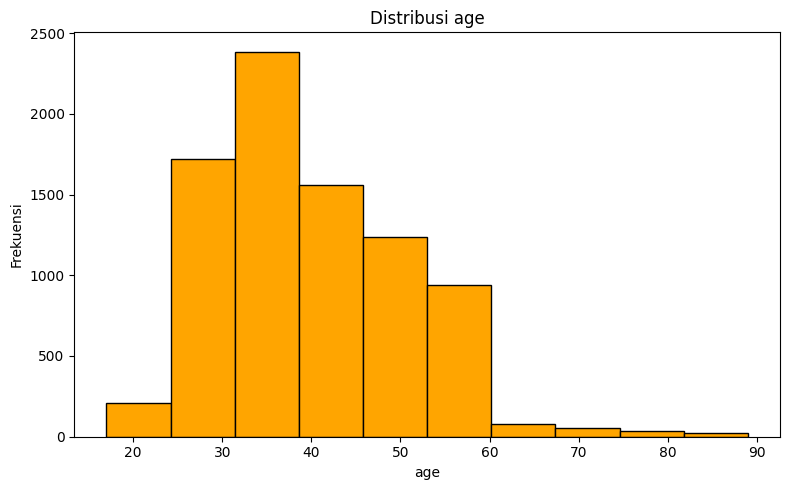

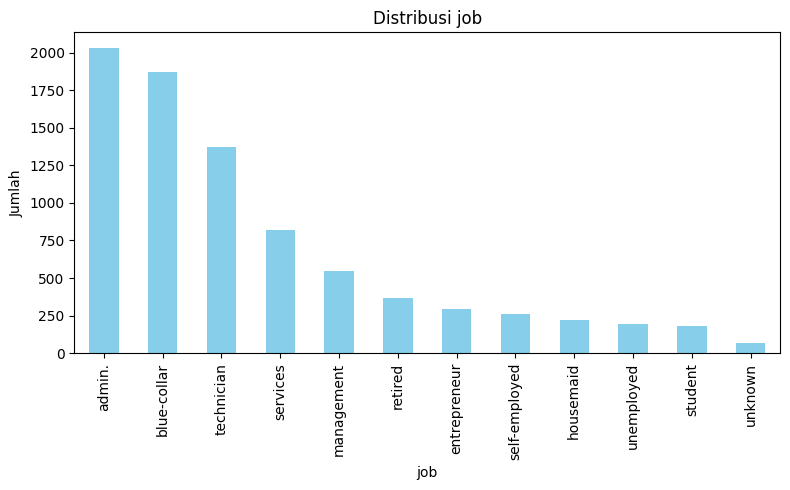

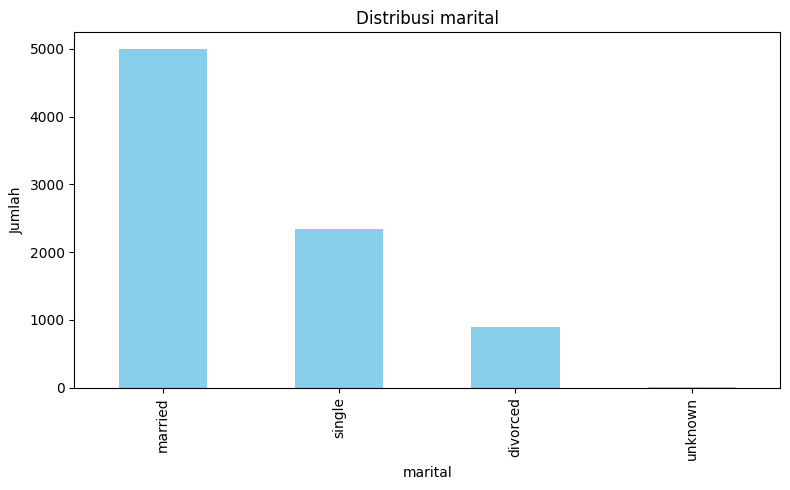

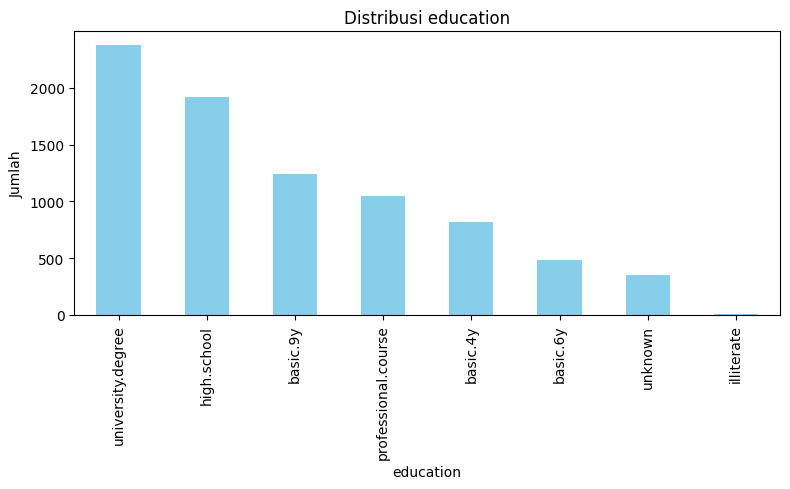

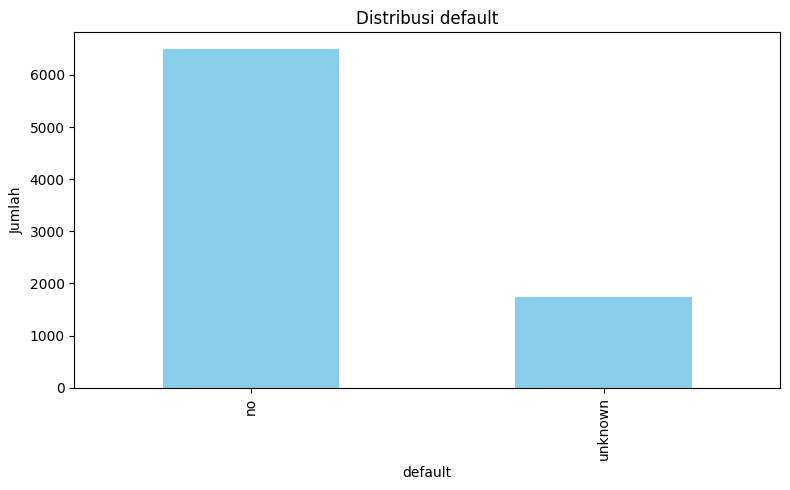

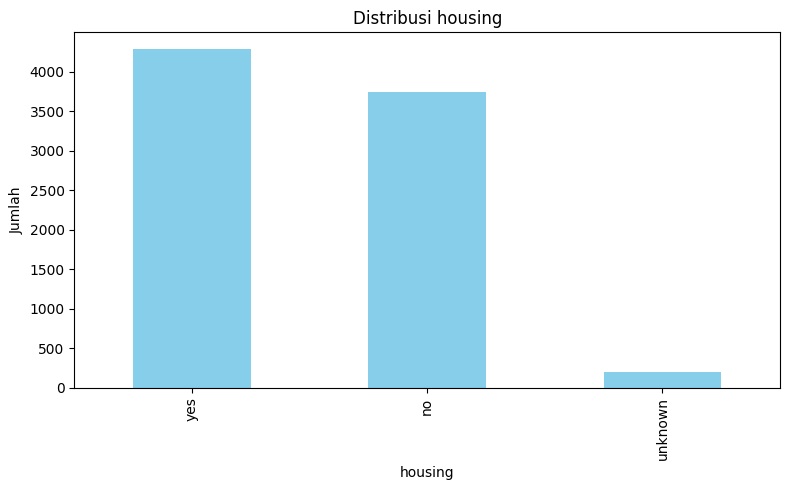

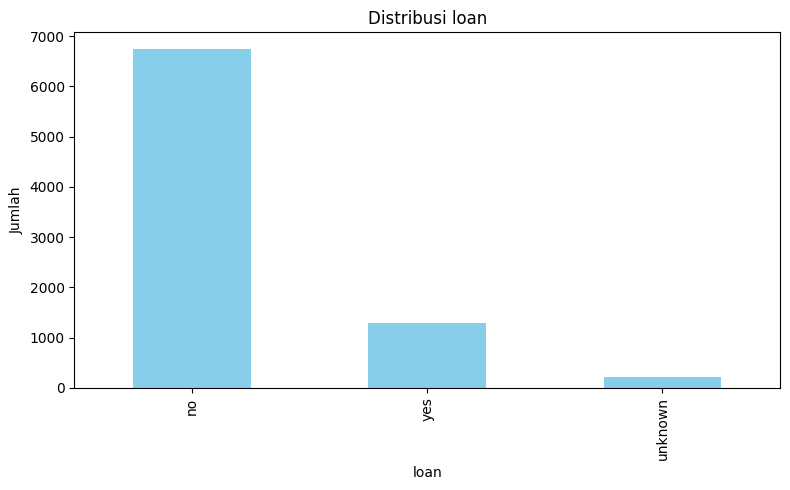

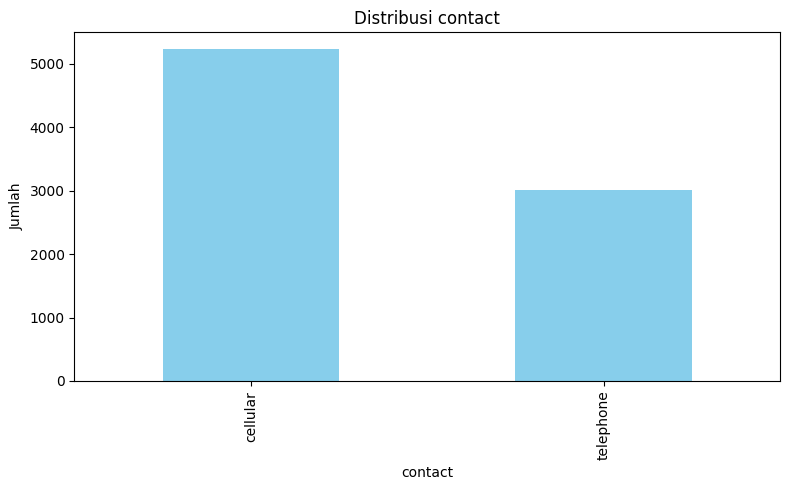

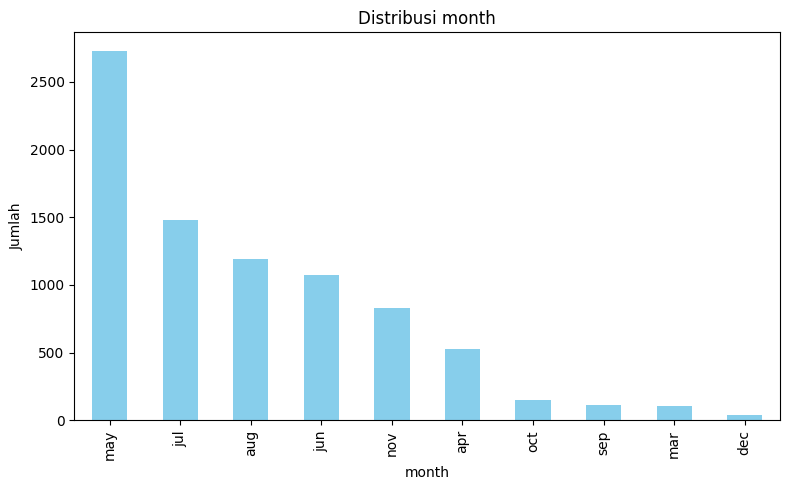

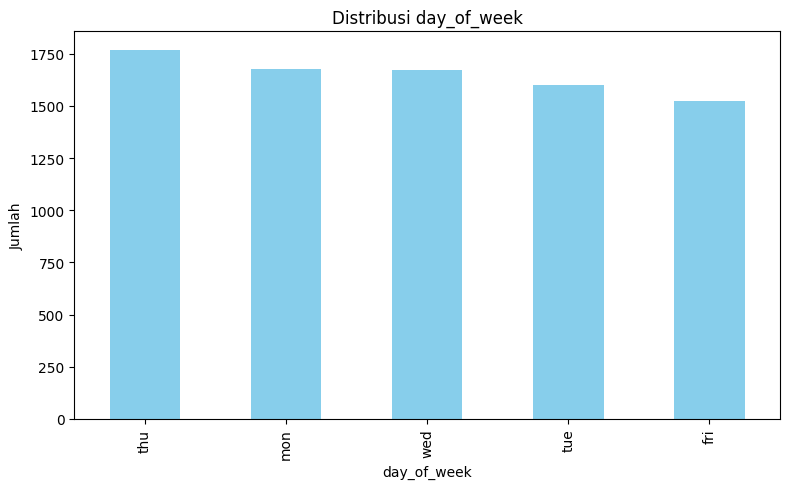

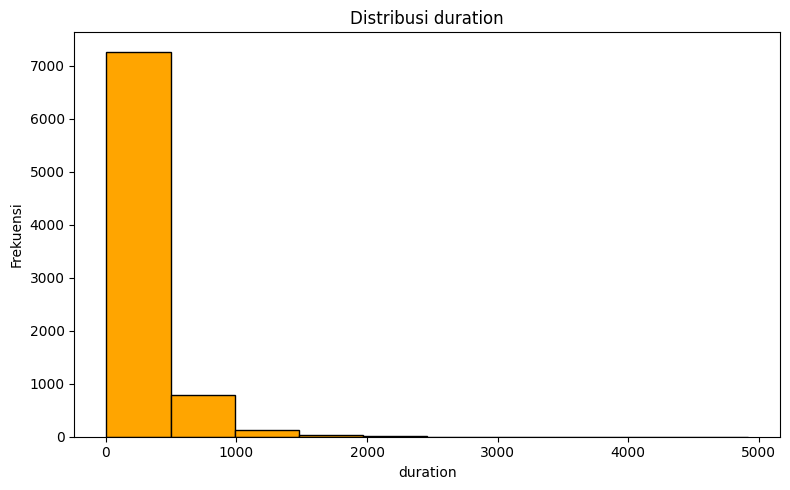

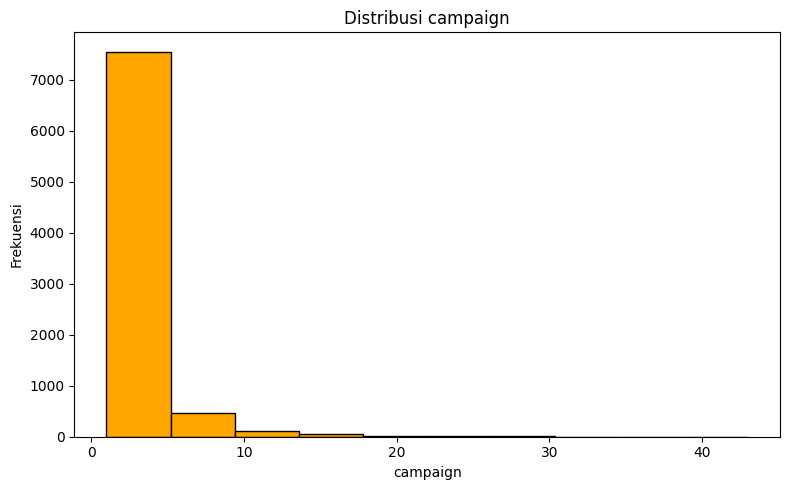

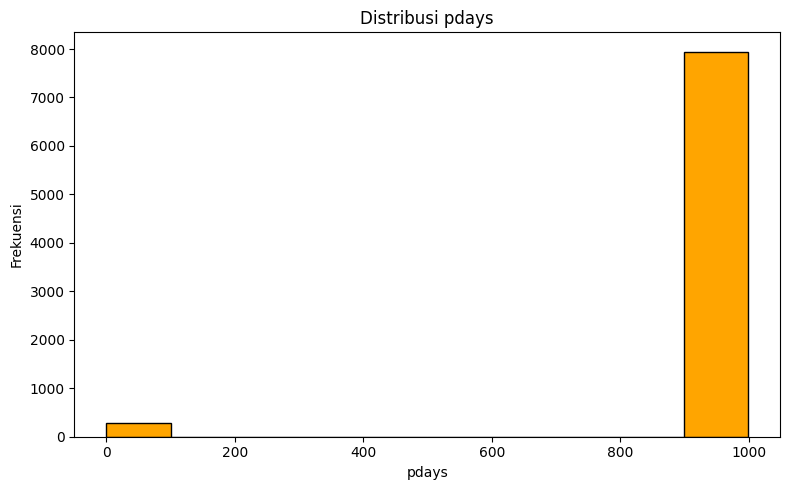

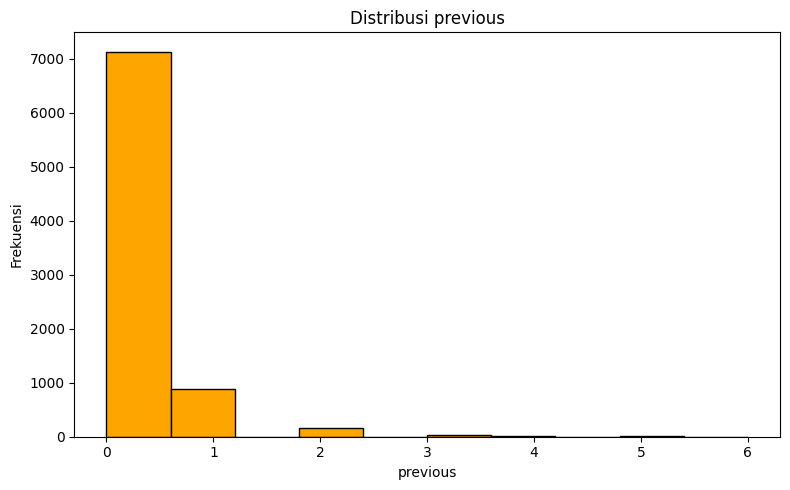

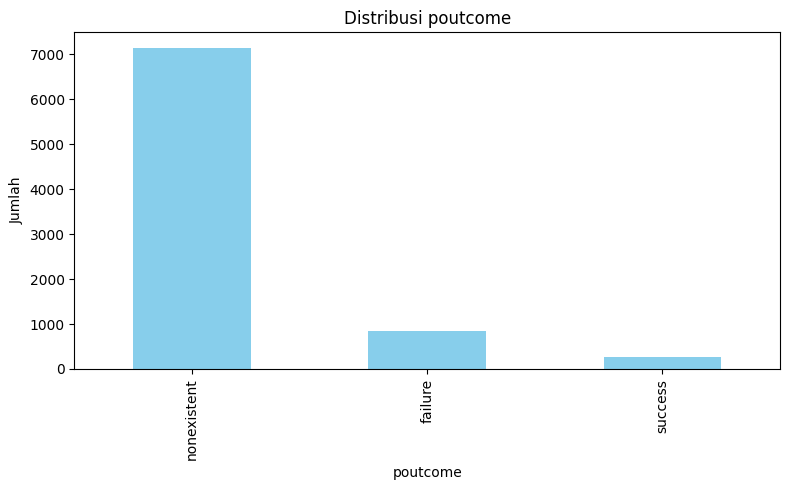

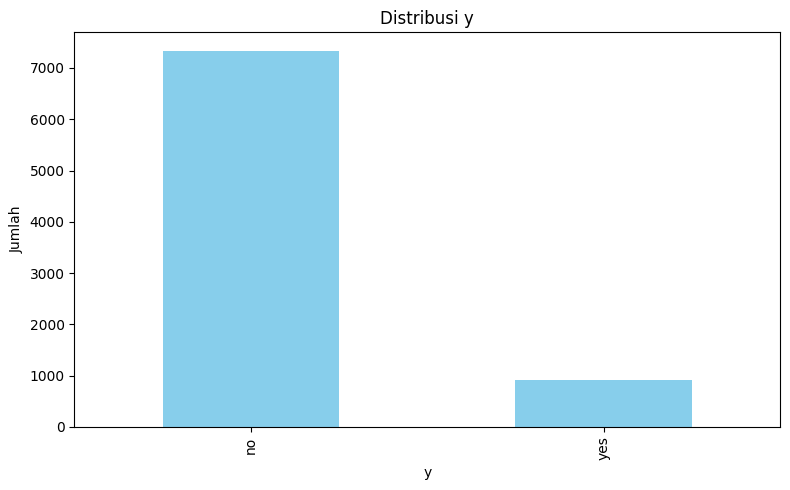

In [9]:
# Fungsi untuk menampilkan plot distribusi satu per satu
def plot_distributions(df):
    for col in df.columns:
        plt.figure(figsize=(8, 5))
        if df[col].dtype == 'object':
            # Jika kolom bertipe objek (kategori atau teks), buat diagram batang
            df[col].value_counts().plot(kind='bar', color='skyblue')
            plt.ylabel('Jumlah')
        else:
            # Jika kolom bertipe numerik, buat histogram
            df[col].plot(kind='hist', color='orange', edgecolor='black')
            plt.ylabel('Frekuensi')
        plt.title(f'Distribusi {col}')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()
        
# Memanggil fungsi untuk menampilkan plot distribusi
plot_distributions(df)

In [10]:
for i in df.columns:
    print(f'Kolom {i}')
    print(df[i].describe())
    print('\n')

Kolom age
count    8238.000000
mean       39.928866
std        10.512521
min        17.000000
25%        32.000000
50%        38.000000
75%        47.000000
max        89.000000
Name: age, dtype: float64


Kolom job
count       8230
unique        12
top       admin.
freq        2033
Name: job, dtype: object


Kolom marital
count        8238
unique          4
top       married
freq         4994
Name: marital, dtype: object


Kolom education
count                  8238
unique                    8
top       university.degree
freq                   2379
Name: education, dtype: object


Kolom default
count     8238
unique       2
top         no
freq      6491
Name: default, dtype: object


Kolom housing
count     8238
unique       3
top        yes
freq      4284
Name: housing, dtype: object


Kolom loan
count     8238
unique       3
top         no
freq      6741
Name: loan, dtype: object


Kolom contact
count         8238
unique           2
top       cellular
freq          5232
Name: contac

In [11]:
df.duplicated().sum()

0

In [12]:
df[df['education'] == 'unknown']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
24,53,housemaid,married,unknown,no,yes,no,cellular,nov,thu,104.0,5,999,0,nonexistent,no
108,43,technician,married,unknown,unknown,yes,yes,telephone,may,mon,325.0,1,999,0,nonexistent,no
112,45,admin.,married,unknown,unknown,no,no,cellular,aug,thu,7.0,14,999,0,nonexistent,no
154,44,student,single,unknown,unknown,no,yes,cellular,jul,tue,113.0,6,999,0,nonexistent,no
155,20,student,single,unknown,no,yes,no,cellular,apr,tue,99.0,1,999,0,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8159,50,technician,married,unknown,no,yes,yes,cellular,may,tue,400.0,1,999,0,nonexistent,yes
8165,28,services,single,unknown,no,no,no,cellular,may,tue,466.0,2,999,1,failure,no
8169,39,blue-collar,divorced,unknown,no,yes,no,cellular,may,thu,40.0,1,999,0,nonexistent,no
8200,43,technician,divorced,unknown,no,no,no,cellular,jul,fri,377.0,1,999,1,failure,no


In [13]:
contingency_table = pd.crosstab(df['education'], df['job'])

# Tampilkan tabel kontingensi
print("Contingency Table (Education vs Job):")
print(contingency_table)

Contingency Table (Education vs Job):
job                  admin.  blue-collar  entrepreneur  housemaid  management  \
education                                                                       
basic.4y                 17          452            33         90          27   
basic.6y                 30          305            11         24          15   
basic.9y                 93          738            48         23          25   
high.school             630          194            46         32          71   
illiterate                0            3             0          1           0   
professional.course      80           73            30         15          18   
university.degree      1138           16           117         28         368   
unknown                  45           89             9          6          22   

job                  retired  self-employed  services  student  technician  \
education                                                                

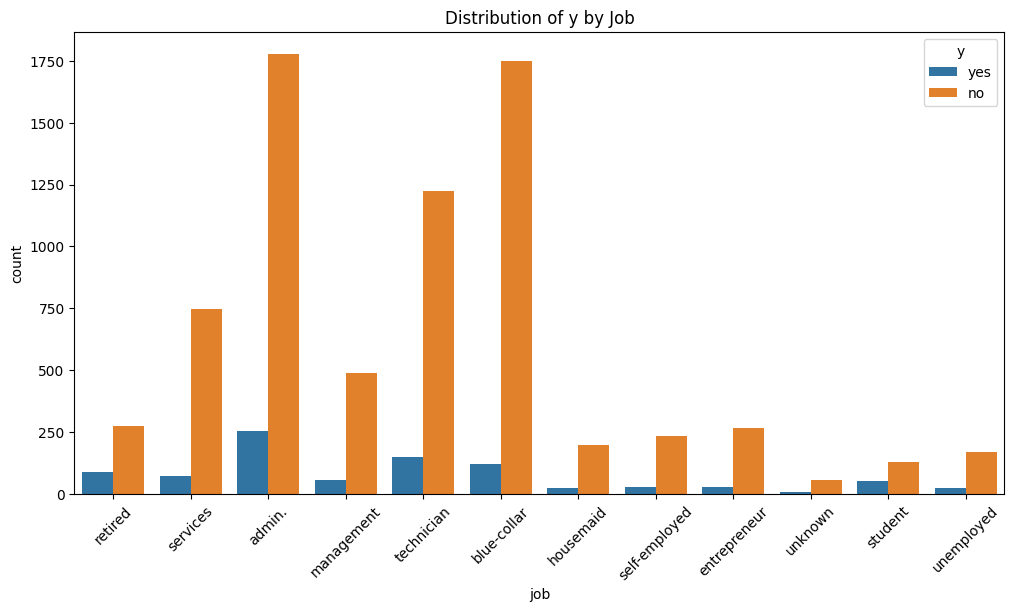

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='job', hue='y')
plt.title('Distribution of y by Job')
plt.xticks(rotation=45)
plt.show()

In [15]:
contingency_table = pd.crosstab(df['job'], df['y'])

# Menjalankan chi-square test
chi2, p, dof, ex = chi2_contingency(contingency_table)

# Menghitung Cramér's V
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"Chi-square test statistic: {chi2}")
print(f"P-value: {p}")
print(f"Cramér's V: {cramers_v}")

Chi-square test statistic: 183.57705926419135
P-value: 1.8707680354971866e-33
Cramér's V: 0.149351396115915


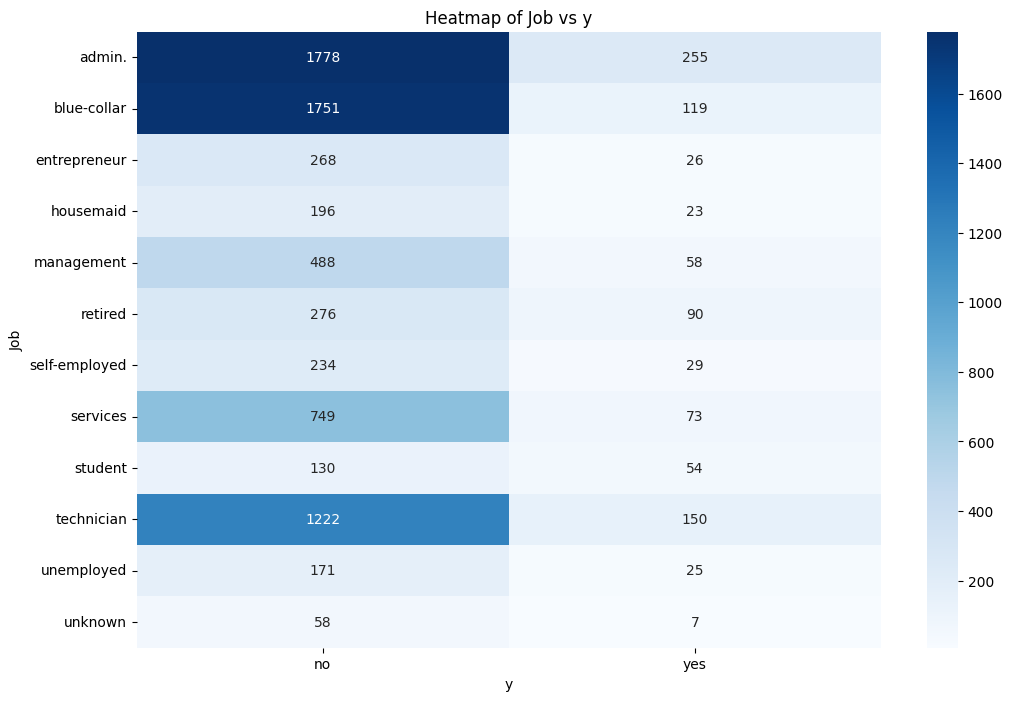

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap of Job vs y')
plt.xlabel('y')
plt.ylabel('Job')
plt.show()

Disini dapat dilihat bahwa job yang 'unknown' kemungkinan tidak signifikan dalam menentukan nilai y, sehingga bisa diremove

In [17]:
contingency_table = pd.crosstab(df['education'], df['y'])

# Menjalankan chi-square test
chi2, p, dof, ex = chi2_contingency(contingency_table)

# Menghitung Cramér's V
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"Chi-square test statistic: {chi2}")
print(f"P-value: {p}")
print(f"Cramér's V: {cramers_v}")

Chi-square test statistic: 45.53733876634864
P-value: 1.0754424467009298e-07
Cramér's V: 0.07434862300635488


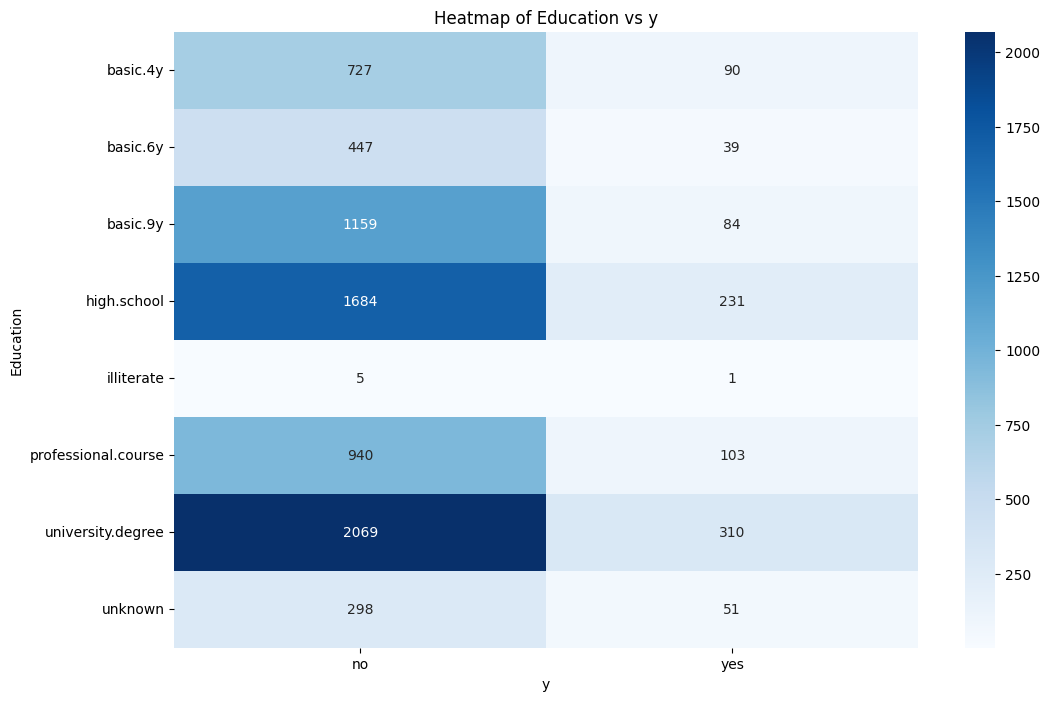

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap of Education vs y')
plt.xlabel('y')
plt.ylabel('Education')
plt.show()

jumlah illiterate yang terlalu kecil menunjukkan bahwa ia tidak terlalu berkontribusi ke output.

# PREPROCESSING DATA

# Splitting data

In [19]:
input_df = df.drop(columns=['y'])
output_df = df['y']

In [20]:
x_train, x_test, y_train, y_test = train_test_split(input_df, output_df, test_size=0.2, random_state=42)

In [21]:
print(x_train.isna().sum())
print(x_test.isna().sum())

age            0
job            5
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       9
campaign       0
pdays          0
previous       0
poutcome       0
dtype: int64
age            0
job            3
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       3
campaign       0
pdays          0
previous       0
poutcome       0
dtype: int64


In [22]:
x_train['job'].unique()

array(['blue-collar', 'technician', 'admin.', 'management', 'services',
       'housemaid', 'retired', 'self-employed', 'entrepreneur', 'student',
       'unemployed', 'unknown', nan], dtype=object)

In [23]:
#mengubah nan menjadi unknown
x_train['job'] = x_train['job'].fillna('unknown')
x_test['job'] = x_test['job'].fillna('unknown')

In [24]:
print(x_train['job'].unique())
print(x_test['job'].unique())

['blue-collar' 'technician' 'admin.' 'management' 'services' 'housemaid'
 'retired' 'self-employed' 'entrepreneur' 'student' 'unemployed' 'unknown']
['admin.' 'technician' 'services' 'retired' 'entrepreneur' 'blue-collar'
 'housemaid' 'self-employed' 'student' 'management' 'unemployed' 'unknown']


In [25]:
x_train['job'].value_counts()

admin.           1620
blue-collar      1488
technician       1117
services          658
management        433
retired           291
entrepreneur      243
self-employed     210
housemaid         172
unemployed        162
student           139
unknown            57
Name: job, dtype: int64

> REMOVING ALL UNKNOWNS

In [26]:
df['job'].mode()

0    admin.
dtype: object

Kemungkinan : mengubah 'unknown' menjadi modus, untuk tetap mempertahankan informasi dari kolom yang lain (karena 73 data itu banyak..ya meskipun dibanding 8000an data ga banyak si tp ttp aja ehehe)

In [27]:
#jadikan unknown ke mode
x_train['job'] = x_train['job'].replace('unknown', 'admin.')
x_test['job'] = x_test['job'].replace('unknown', 'admin.')

In [28]:
x_train['job'].unique()

array(['blue-collar', 'technician', 'admin.', 'management', 'services',
       'housemaid', 'retired', 'self-employed', 'entrepreneur', 'student',
       'unemployed'], dtype=object)

In [29]:
mean_duration = df['duration'].mean()

In [30]:
x_train['duration'] = x_train['duration'].fillna(mean_duration)
x_test['duration'] = x_test['duration'].fillna(mean_duration)

In [31]:
print(x_train.isna().sum())
print('\n')
print(x_test.isna().sum())


age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
dtype: int64


age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
dtype: int64


In [32]:
x_train['marital'].value_counts()

married     4022
single      1862
divorced     696
unknown       10
Name: marital, dtype: int64

In [33]:
x_train['marital'] = x_train['marital'].replace('unknown', 'married')
x_test['marital'] = x_test['marital'].replace('unknown', 'married')

In [34]:
x_train['marital'].value_counts()

married     4032
single      1862
divorced     696
Name: marital, dtype: int64

In [35]:
x_train['education'].value_counts()

university.degree      1906
high.school            1551
basic.9y                997
professional.course     831
basic.4y                663
basic.6y                378
unknown                 259
illiterate                5
Name: education, dtype: int64

In [36]:
x_test['education'].value_counts()

university.degree      473
high.school            364
basic.9y               246
professional.course    212
basic.4y               154
basic.6y               108
unknown                 90
illiterate               1
Name: education, dtype: int64

In [37]:
#mengubah kolom education yg unknown dgn job student menjadi university
def fill_education(row):
    if row['education'] == 'unknown':
        if row['job'] == 'student':
            return 'university.degree'
        else:
            return 'high.school'
    else:
        return row['education']

x_train['education'] = x_train.apply(fill_education, axis=1)
x_test['education'] = x_test.apply(fill_education, axis=1)

In [38]:
#mengubah illiterate ke basic.4y sebagai pendidikan paling dasar
x_train['education'] = x_train['education'].replace('illiterate', 'basic.4y')
x_test['education'] = x_test['education'].replace('illiterate', 'basic.4y')

In [39]:
x_train['education'].value_counts()

university.degree      1932
high.school            1784
basic.9y                997
professional.course     831
basic.4y                668
basic.6y                378
Name: education, dtype: int64

In [40]:
#default
x_train['default'].value_counts()

no         5170
unknown    1420
Name: default, dtype: int64

In [41]:
#drop default karena unknown akan dijadikan no, dan kolom menjadi tidak relevan karena hanya terdapat data 'no' saja
x_train = x_train.drop(columns=['default'])
x_test = x_test.drop(columns=['default'])

In [42]:
#housing
x_train['housing'].value_counts()

yes        3429
no         2989
unknown     172
Name: housing, dtype: int64

In [43]:
x_train['housing'] = x_train['housing'].replace('unknown', 'yes')
x_test['housing'] = x_test['housing'].replace('unknown', 'yes')

In [44]:
#loan
x_train['loan'].value_counts()

no         5373
yes        1045
unknown     172
Name: loan, dtype: int64

In [45]:
x_train['loan'] = x_train['loan'].replace('unknown', 'no')
x_test['loan'] = x_test['loan'].replace('unknown', 'no')

# ENCODING

In [46]:
x_train.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome
3805,31,blue-collar,single,basic.9y,yes,yes,cellular,jun,tue,103.0,1,3,2,success
5900,32,technician,married,professional.course,no,yes,cellular,jul,wed,183.0,1,999,0,nonexistent
5022,47,technician,married,professional.course,yes,yes,cellular,aug,fri,78.0,3,999,0,nonexistent
4556,36,admin.,single,university.degree,yes,no,cellular,jul,thu,10.0,3,999,0,nonexistent
4139,45,management,married,university.degree,no,yes,cellular,nov,wed,391.0,2,999,0,nonexistent


In [47]:
x_train.columns

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome'],
      dtype='object')

In [48]:
# x_train = pd.get_dummies(x_train, columns=['job', 'marital', 'education', 'contact', 'poutcome'], dtype='int')
# x_test = pd.get_dummies(x_test, columns=['job', 'marital', 'education', 'contact', 'poutcome'], dtype='int')

In [49]:
x_train

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome
3805,31,blue-collar,single,basic.9y,yes,yes,cellular,jun,tue,103.0,1,3,2,success
5900,32,technician,married,professional.course,no,yes,cellular,jul,wed,183.0,1,999,0,nonexistent
5022,47,technician,married,professional.course,yes,yes,cellular,aug,fri,78.0,3,999,0,nonexistent
4556,36,admin.,single,university.degree,yes,no,cellular,jul,thu,10.0,3,999,0,nonexistent
4139,45,management,married,university.degree,no,yes,cellular,nov,wed,391.0,2,999,0,nonexistent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,52,technician,married,professional.course,no,no,cellular,aug,thu,67.0,1,999,0,nonexistent
5191,32,services,single,high.school,no,no,cellular,apr,thu,472.0,2,999,0,nonexistent
5390,50,admin.,married,basic.9y,no,no,cellular,aug,thu,23.0,14,999,0,nonexistent
860,39,unemployed,single,basic.9y,yes,no,telephone,may,tue,405.0,1,999,0,nonexistent


In [50]:
x_test

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome
706,46,admin.,divorced,university.degree,no,no,telephone,may,wed,93.0,1,999,0,nonexistent
5968,35,technician,married,high.school,yes,no,cellular,jul,tue,740.0,1,999,0,nonexistent
1665,24,services,single,high.school,yes,no,cellular,jul,wed,242.0,1,999,0,nonexistent
6676,51,admin.,married,high.school,no,no,cellular,may,tue,40.0,4,999,0,nonexistent
5606,36,admin.,married,high.school,yes,no,telephone,jul,tue,305.0,7,999,0,nonexistent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1811,38,services,married,high.school,yes,no,cellular,nov,fri,306.0,1,999,1,failure
296,48,management,married,university.degree,no,no,telephone,may,fri,75.0,1,999,0,nonexistent
6452,33,student,single,university.degree,no,no,cellular,nov,mon,288.0,2,999,0,nonexistent
57,55,management,married,university.degree,no,no,cellular,aug,fri,72.0,1,999,1,failure


In [51]:
#one hot encoding = job, marital, education, contact, poutcome
columns_to_encode = ['job', 'marital', 'education', 'contact', 'poutcome']
one_hot = OneHotEncoder(sparse=False, handle_unknown='ignore')
one_hot.fit(x_train[columns_to_encode])
one_hot.fit(x_test[columns_to_encode])

OneHotEncoder(handle_unknown='ignore', sparse=False)

In [52]:
encode_train = one_hot.transform(x_train[columns_to_encode])
encode_test = one_hot.transform(x_test[columns_to_encode])

In [53]:
encoded_train = pd.DataFrame(encode_train, columns=one_hot.get_feature_names_out(columns_to_encode))
encoded_test = pd.DataFrame(encode_test, columns=one_hot.get_feature_names_out(columns_to_encode))


In [54]:
encoded_train

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6585,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
6586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6587,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [55]:
encoded_test

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1644,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1645,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1646,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


In [56]:
x_train

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome
3805,31,blue-collar,single,basic.9y,yes,yes,cellular,jun,tue,103.0,1,3,2,success
5900,32,technician,married,professional.course,no,yes,cellular,jul,wed,183.0,1,999,0,nonexistent
5022,47,technician,married,professional.course,yes,yes,cellular,aug,fri,78.0,3,999,0,nonexistent
4556,36,admin.,single,university.degree,yes,no,cellular,jul,thu,10.0,3,999,0,nonexistent
4139,45,management,married,university.degree,no,yes,cellular,nov,wed,391.0,2,999,0,nonexistent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,52,technician,married,professional.course,no,no,cellular,aug,thu,67.0,1,999,0,nonexistent
5191,32,services,single,high.school,no,no,cellular,apr,thu,472.0,2,999,0,nonexistent
5390,50,admin.,married,basic.9y,no,no,cellular,aug,thu,23.0,14,999,0,nonexistent
860,39,unemployed,single,basic.9y,yes,no,telephone,may,tue,405.0,1,999,0,nonexistent


In [57]:
x_train.reset_index(inplace=True)
x_test.reset_index(inplace=True)

In [58]:
x_train

,index,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome
0,3805,31,blue-collar,single,basic.9y,yes,yes,cellular,jun,tue,103.0,1,3,2,success
1,5900,32,technician,married,professional.course,no,yes,cellular,jul,wed,183.0,1,999,0,nonexistent
2,5022,47,technician,married,professional.course,yes,yes,cellular,aug,fri,78.0,3,999,0,nonexistent
3,4556,36,admin.,single,university.degree,yes,no,cellular,jul,thu,10.0,3,999,0,nonexistent
4,4139,45,management,married,university.degree,no,yes,cellular,nov,wed,391.0,2,999,0,nonexistent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6585,5734,52,technician,married,professional.course,no,no,cellular,aug,thu,67.0,1,999,0,nonexistent
6586,5191,32,services,single,high.school,no,no,cellular,apr,thu,472.0,2,999,0,nonexistent
6587,5390,50,admin.,married,basic.9y,no,no,cellular,aug,thu,23.0,14,999,0,nonexistent
6588,860,39,unemployed,single,basic.9y,yes,no,telephone,may,tue,405.0,1,999,0,nonexistent


In [59]:
final_x_train = pd.concat([x_train.drop(columns=columns_to_encode), encoded_train], axis=1)
final_x_test = pd.concat([x_test.drop(columns=columns_to_encode), encoded_test], axis=1)


In [60]:
print(final_x_train)

      index  age housing loan month day_of_week  duration  campaign  pdays  \
0      3805   31     yes  yes   jun         tue     103.0         1      3   
1      5900   32      no  yes   jul         wed     183.0         1    999   
2      5022   47     yes  yes   aug         fri      78.0         3    999   
3      4556   36     yes   no   jul         thu      10.0         3    999   
4      4139   45      no  yes   nov         wed     391.0         2    999   
...     ...  ...     ...  ...   ...         ...       ...       ...    ...   
6585   5734   52      no   no   aug         thu      67.0         1    999   
6586   5191   32      no   no   apr         thu     472.0         2    999   
6587   5390   50      no   no   aug         thu      23.0        14    999   
6588    860   39     yes   no   may         tue     405.0         1    999   
6589   7270   46      no   no   may         wed     117.0         3    999   

      previous  ...  education_basic.6y  education_basic.9y  \


In [61]:
final_x_train.drop(columns=['index'], inplace=True)
final_x_test.drop(columns=['index'], inplace=True)

In [62]:
final_x_train = pd.DataFrame(final_x_train)

In [63]:
final_x_train

,age,housing,loan,month,day_of_week,duration,campaign,pdays,previous,job_admin.,...,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success
0,31,yes,yes,jun,tue,103.0,1,3,2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,32,no,yes,jul,wed,183.0,1,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,47,yes,yes,aug,fri,78.0,3,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,36,yes,no,jul,thu,10.0,3,999,0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,45,no,yes,nov,wed,391.0,2,999,0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6585,52,no,no,aug,thu,67.0,1,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
6586,32,no,no,apr,thu,472.0,2,999,0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6587,50,no,no,aug,thu,23.0,14,999,0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6588,39,yes,no,may,tue,405.0,1,999,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [64]:
final_x_test = pd.DataFrame(final_x_test)

In [65]:
x_train = final_x_train
x_train

,age,housing,loan,month,day_of_week,duration,campaign,pdays,previous,job_admin.,...,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success
0,31,yes,yes,jun,tue,103.0,1,3,2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,32,no,yes,jul,wed,183.0,1,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,47,yes,yes,aug,fri,78.0,3,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,36,yes,no,jul,thu,10.0,3,999,0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,45,no,yes,nov,wed,391.0,2,999,0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6585,52,no,no,aug,thu,67.0,1,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
6586,32,no,no,apr,thu,472.0,2,999,0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6587,50,no,no,aug,thu,23.0,14,999,0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6588,39,yes,no,may,tue,405.0,1,999,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [66]:
x_test = final_x_test

In [67]:
filename = "one_hot.pkl"
pkl.dump(one_hot, open(filename, 'wb'))

In [68]:
#binary encoding = housing, loan
label_encoder = LabelEncoder()

# x_train['housing'] = x_train['housing'].map({'yes': 1, 'no': 0})
# x_test['housing'] = x_test['housing'].map({'yes': 1, 'no': 0})
# x_train['loan'] = x_train['loan'].map({'yes': 1, 'no': 0})
# x_test['loan'] = x_test['loan'].map({'yes': 1, 'no': 0})

In [69]:
x_train

,age,housing,loan,month,day_of_week,duration,campaign,pdays,previous,job_admin.,...,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success
0,31,yes,yes,jun,tue,103.0,1,3,2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,32,no,yes,jul,wed,183.0,1,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,47,yes,yes,aug,fri,78.0,3,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,36,yes,no,jul,thu,10.0,3,999,0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,45,no,yes,nov,wed,391.0,2,999,0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6585,52,no,no,aug,thu,67.0,1,999,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
6586,32,no,no,apr,thu,472.0,2,999,0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6587,50,no,no,aug,thu,23.0,14,999,0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6588,39,yes,no,may,tue,405.0,1,999,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [70]:
x_train['housing_encoded'] = label_encoder.fit_transform(x_train['housing'])
x_test['housing_encoded'] = label_encoder.fit_transform(x_test['housing'])

x_train['loan_encoded'] = label_encoder.fit_transform(x_train['loan'])
x_test['loan_encoded'] = label_encoder.fit_transform(x_test['loan'])

In [71]:
x_train

,age,housing,loan,month,day_of_week,duration,campaign,pdays,previous,job_admin.,...,education_high.school,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success,housing_encoded,loan_encoded
0,31,yes,yes,jun,tue,103.0,1,3,2,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,1
1,32,no,yes,jul,wed,183.0,1,999,0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0,1
2,47,yes,yes,aug,fri,78.0,3,999,0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1,1
3,36,yes,no,jul,thu,10.0,3,999,0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1,0
4,45,no,yes,nov,wed,391.0,2,999,0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6585,52,no,no,aug,thu,67.0,1,999,0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
6586,32,no,no,apr,thu,472.0,2,999,0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
6587,50,no,no,aug,thu,23.0,14,999,0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
6588,39,yes,no,may,tue,405.0,1,999,0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,0


In [72]:
x_train.drop(columns=['housing', 'loan'], inplace=True)
x_test.drop(columns=['housing', 'loan'], inplace=True)

In [73]:
x_train.rename(columns={'housing_encoded': 'housing', 'loan_encoded': 'loan'}, inplace=True)
x_test.rename(columns={'housing_encoded': 'housing', 'loan_encoded': 'loan'}, inplace=True)


In [74]:
filename = "binary.pkl"
pkl.dump(label_encoder, open(filename, 'wb'))

In [75]:
#label encoding = month, day_of_week
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
day_of_week_order = ['mon', 'tue', 'wed', 'thu', 'fri']

ordinal_encoder = OrdinalEncoder(categories=[month_order, day_of_week_order])
x_train[['month', 'day_of_week']] = ordinal_encoder.fit_transform(x_train[['month', 'day_of_week']])
x_test[['month', 'day_of_week']] = ordinal_encoder.fit_transform(x_test[['month', 'day_of_week']])

In [76]:
x_train.head()


,age,month,day_of_week,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,education_high.school,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success,housing,loan
0,31,5.0,1.0,103.0,1,3,2,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,1
1,32,6.0,2.0,183.0,1,999,0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0,1
2,47,7.0,4.0,78.0,3,999,0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1,1
3,36,6.0,3.0,10.0,3,999,0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1,0
4,45,10.0,2.0,391.0,2,999,0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0,1


In [77]:
filename = "ordinal.pkl"
pkl.dump(ordinal_encoder, open(filename, 'wb'))

In [78]:
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [79]:
x_test.head()

,age,month,day_of_week,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,education_high.school,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success,housing,loan
0,46,4.0,2.0,93.0,1,999,0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0
1,35,6.0,1.0,740.0,1,999,0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0
2,24,6.0,2.0,242.0,1,999,0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0
3,51,4.0,1.0,40.0,4,999,0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
4,36,6.0,1.0,305.0,7,999,0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,0


In [80]:
print(f"Distribusi kelas sebelum SMOTE: {Counter(y_train)}")
print(f"Distribusi kelas setelah SMOTE: {Counter(y_train_res)}")


Distribusi kelas sebelum SMOTE: Counter({'no': 5894, 'yes': 696})
Distribusi kelas setelah SMOTE: Counter({'yes': 5894, 'no': 5894})


In [81]:
#coba random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [82]:
y_pred = rf_model.predict(x_test)

In [83]:
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

              precision    recall  f1-score   support

          no       0.91      0.98      0.94      1435
         yes       0.70      0.37      0.48       213

    accuracy                           0.90      1648
   macro avg       0.81      0.67      0.71      1648
weighted avg       0.89      0.90      0.88      1648

Confusion Matrix:
[[1401   34]
 [ 134   79]]


krn oversampling, kemungkinan dia terjadi overfitting di yes

In [84]:
y_train = y_train.map({'yes': 1, 'no': 0})
y_test = y_test.map({'yes': 1, 'no': 0})
y_train_res = y_train_res.map({'yes': 1, 'no': 0})

In [85]:
#coba pake boosting models yang bisa handle class imbalance
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_bin=256, max_cat_to_onehot=4, max_delta_step=0, max_depth=6,
              max_leaves=0, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=0,
              num_parallel_tree=1, predictor='auto', random_state=42,
              reg_alpha=0, reg_lambda=1, ...)

In [86]:
y_pred = xgb_model.predict(x_test)


In [87]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi: {accuracy:.2f}')

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

Akurasi: 0.89
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1435
           1       0.61      0.40      0.49       213

    accuracy                           0.89      1648
   macro avg       0.77      0.68      0.71      1648
weighted avg       0.88      0.89      0.88      1648

Confusion Matrix:
[[1381   54]
 [ 127   86]]


In [88]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train_res, y_train_res)
y_y = xgb_model.predict(x_test)

In [89]:
accuracy = accuracy_score(y_test, y_y)
print(f'Akurasi: {accuracy:.2f}')

# Classification report
print(classification_report(y_test, y_y))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_y)
print('Confusion Matrix:')
print(conf_matrix)

Akurasi: 0.89
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1435
           1       0.62      0.39      0.48       213

    accuracy                           0.89      1648
   macro avg       0.77      0.68      0.71      1648
weighted avg       0.88      0.89      0.88      1648

Confusion Matrix:
[[1384   51]
 [ 129   84]]


In [90]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 2, 5]  # Untuk menangani ketidakseimbangan kelas
}


In [91]:
grid_search = GridSearchCV(estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=1)


In [92]:
y_train_res

0        1
1        0
2        0
3        0
4        0
        ..
11783    1
11784    1
11785    1
11786    1
11787    1
Name: y, Length: 11788, dtype: int64

In [93]:
grid_search.fit(x_train_res, y_train_res)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     m...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, 

In [94]:
best_xgb_model = grid_search.best_estimator_

In [95]:
y_pred_best = best_xgb_model.predict(x_test)

In [96]:
# Evaluasi model terbaik
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f'Akurasi dengan model terbaik: {accuracy_best:.2f}')
print(classification_report(y_test, y_pred_best))

Akurasi dengan model terbaik: 0.89
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1435
           1       0.60      0.54      0.57       213

    accuracy                           0.89      1648
   macro avg       0.77      0.75      0.75      1648
weighted avg       0.89      0.89      0.89      1648



lebih membaik dengan SMOTE + XGBOOST TUNED

coba ADASYN + XGBOOST TUNED

In [103]:
y_train

3805    1
5900    0
5022    0
4556    0
4139    0
       ..
5734    0
5191    0
5390    0
860     0
7270    0
Name: y, Length: 6590, dtype: int64

In [109]:
adasyn = ADASYN(random_state=42)
x_train_adasyn, y_train_adasyn = adasyn.fit_resample(x_train, y_train)

In [110]:
y_train_adasyn

0        1
1        0
2        0
3        0
4        0
        ..
11805    1
11806    1
11807    1
11808    1
11809    1
Name: y, Length: 11810, dtype: int64

In [111]:
grid_search.fit(x_train_adasyn, y_train_adasyn)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     m...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, 

In [112]:
best_xgb_model_adasyn = grid_search.best_estimator_

In [113]:
y_pred_adasyn = best_xgb_model_adasyn.predict(x_test)

In [114]:
print("ADASYN Classification Report")
print(classification_report(y_test, y_pred_adasyn))

ADASYN Classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1435
           1       0.62      0.44      0.52       213

    accuracy                           0.89      1648
   macro avg       0.77      0.70      0.73      1648
weighted avg       0.88      0.89      0.89      1648



Untuk performa di class "yes" sendiri, performanya lebih baik jika digabung antara SMOTE dengan XGBOOST + Grid Search. Karena itu akan menggunakan model tersebut.

In [115]:
filename = "XGBnSMOTE.pkl"
pkl.dump(best_xgb_model, open(filename, 'wb'))